In [8]:
import pandas as pd
import ipaddress

# Load data
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# ====================== IP CONVERSION ======================
# Convert ip_address to integer (remove decimal if any)
fraud['ip_address'] = fraud['ip_address'].astype(str).str.split('.').str[0]
fraud['ip_int'] = pd.to_numeric(fraud['ip_address'], errors='coerce').astype('Int64')

# Define function that accepts integer
def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(int(ip)))
    except:
        return None

# Apply conversion
fraud['ip_int'] = fraud['ip_int'].apply(ip_to_int)

# Convert country IP bounds
ip_country['lower_bound_int'] = ip_country['lower_bound_ip_address'].astype('int64')
ip_country['upper_bound_int'] = ip_country['upper_bound_ip_address'].astype('int64')

print(" IP Conversion Done!")
print(f"Successful conversions: {fraud['ip_int'].notnull().sum()} out of {len(fraud)}")
print(fraud[['ip_address', 'ip_int']].head(10))

 IP Conversion Done!
Successful conversions: 151112 out of 151112
   ip_address      ip_int
0   732758368   732758368
1   350311387   350311387
2  2621473820  2621473820
3  3840542443  3840542443
4   415583117   415583117
5  2809315199  2809315199
6  3987484328  3987484328
7  1692458727  1692458727
8  3719094257  3719094257
9   341674739   341674739


In [9]:
# ====================== MERGE WITH COUNTRY ======================

# Sort both tables (very important for merge_asof)
ip_country = ip_country.sort_values('lower_bound_int')
fraud = fraud.sort_values('ip_int')

# Perform the range-based merge
fraud = pd.merge_asof(
    fraud, 
    ip_country,
    left_on='ip_int', 
    right_on='lower_bound_int',
    direction='backward'
)

# Keep only rows where IP is within the valid range
fraud = fraud[fraud['ip_int'] <= fraud['upper_bound_int']]

# Drop unnecessary columns
fraud.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address', 
                    'lower_bound_int', 'upper_bound_int', 'ip_int'], 
           inplace=True, errors='ignore')

print("✅ Merge with Country Completed Successfully!")
print("Total rows after merge:", len(fraud))
print("\nTop 10 Countries:")
print(fraud['country'].value_counts().head(15))

# Save the processed dataset
fraud.to_csv('../data/processed/fraud_data_processed.csv', index=False)
print("\n✅ Processed file saved successfully!")

✅ Merge with Country Completed Successfully!
Total rows after merge: 129146

Top 10 Countries:
country
United States                      58049
China                              12038
Japan                               7306
United Kingdom                      4490
Korea Republic of                   4162
Germany                             3646
France                              3161
Canada                              2975
Brazil                              2961
Italy                               1944
Australia                           1844
Netherlands                         1680
Russian Federation                  1616
India                               1310
Taiwan; Republic of China (ROC)     1237
Name: count, dtype: int64

✅ Processed file saved successfully!


In [10]:
# ====================== FEATURE ENGINEERING ======================

# Make sure datetime columns are correct
fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

# 1. Time Since Signup (in hours)
fraud['time_since_signup'] = (fraud['purchase_time'] - fraud['signup_time']).dt.total_seconds() / 3600

# 2. Hour of Day & Day of Week
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek   # 0=Monday, 6=Sunday

# 3. Simple Transaction Velocity (per user)
fraud = fraud.sort_values(['user_id', 'purchase_time'])

# Time difference from previous

In [11]:
# Save final processed version
fraud.to_csv('../data/processed/fraud_data_processed.csv', index=False)
print("Final processed file saved!")

Final processed file saved!


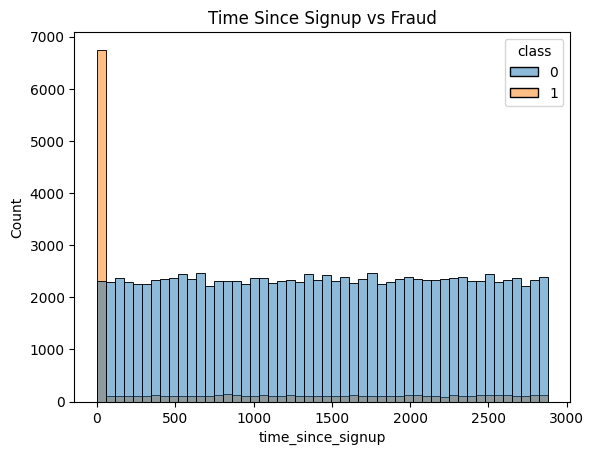

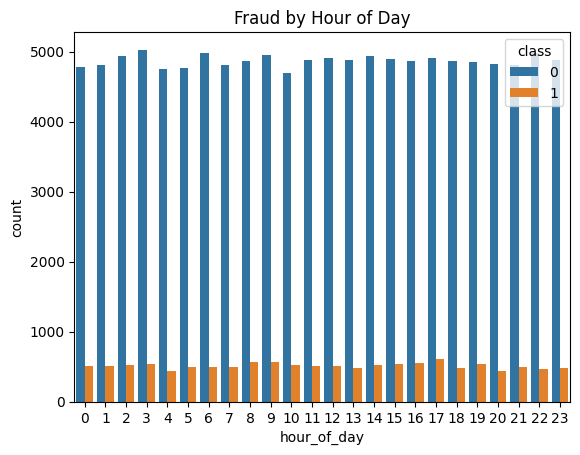

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=fraud, x='time_since_signup', hue='class', bins=50)
plt.title('Time Since Signup vs Fraud')
plt.show()

sns.countplot(x='hour_of_day', hue='class', data=fraud)
plt.title('Fraud by Hour of Day')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [14]:
# ========================= LOAD PROCESSED DATA =========================
fraud = pd.read_csv('../data/processed/fraud_data_processed.csv')

print("Original shape:", fraud.shape)
print("Class distribution before anything:\n", fraud['class'].value_counts(normalize=True))

Original shape: (129146, 15)
Class distribution before anything:
 class
0    0.905007
1    0.094993
Name: proportion, dtype: float64


In [15]:
# Target
y = fraud['class']
X = fraud.drop(columns=['class'])

# Numerical and Categorical columns
numeric_features = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 
                   'day_of_week', 'transactions_last_24h', 'time_diff_prev']

categorical_features = ['source', 'browser', 'sex', 'country']

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'transactions_last_24h', 'time_diff_prev']
Categorical features: ['source', 'browser', 'sex', 'country']


In [16]:
# Stratified split to keep class ratio same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (103316, 14)
Test shape: (25830, 14)
